# Generator — 初始粒子分布生成器

本 Notebook 是独立的初始束团分布生成工具，用于调用 **Generator** 程序生成粒子分布文件（`bunch.ini`）。

- **可独立使用**：仅需 Generator 可执行文件，无需 ASTRA
- **可配合 ASTRA**：生成的 `bunch.ini` 可直接作为 `astra_interface.ipynb` 的输入

依次运行所有单元格即可完成：参数设置 → 运行 Generator → 统计分析 → 可视化。

## Initialization

In [17]:
# 初始化：导入工具模块 & 环境检测

import utils
import platform
from pathlib import Path

# ---- 工作目录 ----
PROJECT_DIR = Path.cwd().resolve()
SIM_DIR = PROJECT_DIR / "simulation_files"
SIM_DIR.mkdir(parents=True, exist_ok=True)

utils.logger.info(f"项目目录 (PROJECT_DIR): {PROJECT_DIR}")
utils.logger.info(f"工作目录 (SIM_DIR):     {SIM_DIR}")

# ---- 系统版本 ----
OS_VERSION = f"{platform.system()} {platform.release()} ({platform.mac_ver()[0] or 'N/A'})"

# ---- 检测 Generator 可执行文件 ----
GENERATOR_EXE = utils.check_executable("generator", fallback_dir=PROJECT_DIR)
GENERATOR_VERSION = utils.get_version(GENERATOR_EXE, SIM_DIR)

utils.logger.info("环境检测通过，可以开始生成初始分布。")

# ---- 环境汇总 ----
utils.print_environment_header(
    tool_name="Generator",
    tool_version=GENERATOR_VERSION,
    sim_dir=SIM_DIR,
    os_version=OS_VERSION,
)

INFO: 项目目录 (PROJECT_DIR): /Users/yuxinwu/astra_notebook
INFO: 工作目录 (SIM_DIR):     /Users/yuxinwu/astra_notebook/simulation_files
INFO: ✓ 在 PATH 中找到 generator: /Users/yuxinwu/ASTRA/generator
INFO: 环境检测通过，可以开始生成初始分布。



  Generator 初始化完成 — 2026-07-04 23:41:00
  操作系统             Darwin 25.5.0 (26.5.1)
  Generator            Version 1.0 - macOS 64bit - Apple Silicon
  工作目录             /Users/yuxinwu/astra_notebook/simulation_files
  首选解析器           ocelot



## Generator Input

Generator 使用 `&INPUT` namelist。有两种方式提供输入参数：

1. **使用现有 `.in` 文件**（推荐直接导入已有配置）：设置 `USE_EXISTING_GENERATOR_INPUT = True`，指定 `EXISTING_GENERATOR_INPUT_FILE` 路径
2. **通过 Python 字典生成**（默认）：修改下方 `gen_params` 字典即可调整初始束团属性，自动生成 `generator.in`

完整参数列表参见 `README.md` 或 ASTRA 手册第 7 章。

In [ ]:
# Generator 输入参数

import shutil

# ---- 输入模式切换 ----
# True=导入现有 .in 文件, False=下方字典自动生成（默认）
USE_EXISTING_GENERATOR_INPUT = True

# ---- 模式 A：使用现有 .in 文件（USE_EXISTING_GENERATOR_INPUT=True 时生效）----
EXISTING_GENERATOR_INPUT_FILE = SIM_DIR / "generator.in"  # 使用 manual example 的 generator.in

# ---- 通用设置 ----
REF_ENERGY_MEV = None  # 参考能量 [MeV]，None=使用 gen_params 中的 Ref_Ekin（模式 B）或自动检测

# ---- 模式 B：Python 字典生成（USE_EXISTING_GENERATOR_INPUT=False 时生效）----
# 完整参数列表参考 ASTRA 手册第 7 章（Generator &INPUT namelist）
# 示例：100 pC 电子束，1 GeV，Gauss 分布，σ_z=1 mm，σ_x=σ_y=0.5 mm

gen_params = {
    # -- 基本输出 --
    "FNAME": "'Example.ini'",      # 输出分布文件名（需加引号）
    "IPart": 500,                  # 生成粒子数
    "Species": "'electrons'",      # 粒子种类: 'electrons', 'protons'
    "Q_total": 1.0,                # 束团总电荷 [nC]
    
    # -- 选项开关 --
    "Probe": True,                 # 是否生成探针粒子
    "Noise_reduc": True,           # Hammersley 准随机降噪
    "Cathode": False,              # 阴极发射模式（T=时间分布, F=空间分布）
    "Add": False,                  # 是否从外部文件添加粒子
    "N_add": 0,                    # 添加的粒子数
    
    # -- 参考能量 & 位置 --
    "Ref_Ekin": 1000.0,            # 参考粒子动能 [MeV]
    "Ref_zpos": 0.0,               # 参考粒子 z 位置 [m]
    "Ref_clock": 0.0,              # 参考粒子初始时钟值 [ns]
    
    # -- 纵向分布 (z) --
    "Dist_z": "'gauss'",           # 纵向分布类型: 'gauss','uniform','plateau','inverted'
    "sig_z": 0.75E0,                  # RMS 束团长度 [mm]
    "C_sig_z": 2.0,                # Gauss 截断倍数（0=不截断）
    
    # -- 纵向动量分布 (pz) --
    "Dist_pz": "'g'",              # 纵向动量分布: 'g'=gauss, 'u'=uniform
    "sig_Ekin": 1.5,               # RMS 能量散度 [keV]
    "cor_Ekin": 0.0E0,               # z–E 相关能散 [keV]
    
    # -- 横向分布 (x, y) --
    "Dist_x": "'gauss'",           # x 横向分布类型: 'gauss', 'uniform'
    "sig_x": 0.75E0,                  # RMS x 尺寸 [mm]
    "Dist_y": "'gauss'",           # y 横向分布类型
    "sig_y": 0.75E0,                  # RMS y 尺寸 [mm]
    
    # -- 横向动量分布 & 发射度 --
    "Dist_px": "'g'",              # x 横向动量分布: 'g'=gauss
    "Nemit_x": 1.0E0,                # x 归一化发射度 [π·mrad·mm]
    "cor_px": 0.0E0,                 # x–px 相关散角 [mrad]
    "Dist_py": "'g'",              # y 横向动量分布
    "Nemit_y": 1.0E0,                # y 归一化发射度 [π·mrad·mm]
    "cor_py": 0.0E0,                 # y–py 相关散角 [mrad]
}

# ---- 文件路径 ----
GEN_INPUT_FILE = SIM_DIR / "generator.in"
GEN_OUTPUT_FILE = None  # 运行时自动检测（模式 B 会预先设置）

# ============================================================
# 生成 / 导入 generator.in
# ============================================================
if USE_EXISTING_GENERATOR_INPUT:
    # ---- 模式 A：导入现有 .in 文件 ----
    existing_path = Path(EXISTING_GENERATOR_INPUT_FILE)
    if not existing_path.is_absolute():
        existing_path = PROJECT_DIR / existing_path
    
    if not existing_path.exists():
        raise FileNotFoundError(
            f"指定的 Generator 输入文件不存在: {existing_path}\n"
            f"请检查 EXISTING_GENERATOR_INPUT_FILE 变量。"
        )
    
    # 如果源文件和目标文件相同，跳过复制
    if existing_path.resolve() == GEN_INPUT_FILE.resolve():
        utils.logger.info(f"Generator 输入文件已在目标位置: {GEN_INPUT_FILE}")
        print(f"--- 使用现有 Generator 输入文件（已在目标位置）---")
        print(f"  文件: {GEN_INPUT_FILE}")
    else:
        shutil.copy2(existing_path, GEN_INPUT_FILE)
        utils.logger.info(f"已导入现有 Generator 输入文件: {existing_path}")
        utils.logger.info(f"  → 复制到: {GEN_INPUT_FILE}")
        print(f"--- 使用现有 Generator 输入文件 ---")
        print(f"  源文件: {existing_path}")
        print(f"  目标:   {GEN_INPUT_FILE}")
    
    # 自动转换 CRLF → LF（兼容 macOS/Linux 上的 Fortran 运行时）
    raw = GEN_INPUT_FILE.read_text(encoding="utf-8")
    if "\r\n" in raw:
        GEN_INPUT_FILE.write_text(raw.replace("\r\n", "\n"), encoding="utf-8")
        utils.logger.info("已自动转换换行符: CRLF → LF")
    
    print(f"\n--- generator.in 内容预览 ---")
    with open(GEN_INPUT_FILE, "r") as f:
        for line in f:
            print(line, end="")
    print()

else:
    # ---- 模式 B：通过 Python 字典生成 generator.in ----
    GEN_OUTPUT_FILENAME = gen_params["FNAME"].strip("'")  # 'bunch.ini' -> bunch.ini
    GEN_OUTPUT_FILE = SIM_DIR / GEN_OUTPUT_FILENAME
    
    utils.write_namelist("INPUT", gen_params, GEN_INPUT_FILE)
    utils.logger.info(f"已通过字典生成 Generator 输入文件: {GEN_INPUT_FILE}")
    
    print("--- generator.in 内容预览 ---")
    with open(GEN_INPUT_FILE, "r") as f:
        for line in f:
            print(line, end="")
    print()

INFO: Namelist 文件已写入: /Users/yuxinwu/astra_notebook/simulation_files/generator.in
INFO: 已通过字典生成 Generator 输入文件: /Users/yuxinwu/astra_notebook/simulation_files/generator.in


--- generator.in 内容预览 ---
&INPUT
  FNAME='Example.ini',
  IPart=500,
  Species='electrons',
  Q_total=1,
  Probe=T,
  Noise_reduc=T,
  Cathode=F,
  Add=F,
  N_add=0,
  Ref_Ekin=1000,
  Ref_zpos=0,
  Ref_clock=0,
  Dist_z='gauss',
  sig_z=0.75,
  C_sig_z=2,
  Dist_pz='g',
  sig_Ekin=1.5,
  cor_Ekin=0,
  Dist_x='gauss',
  sig_x=0.75,
  Dist_y='gauss',
  sig_y=0.75,
  Dist_px='g',
  Nemit_x=1,
  cor_px=0,
  Dist_py='g',
  Nemit_y=1,
  cor_py=0,
 /



## Generator Start

In [19]:
# 运行 Generator

import time

print("\n--- 运行 Generator ---")
t_start = time.perf_counter()
result_gen = utils.run_exe(GENERATOR_EXE, SIM_DIR, input_file=str(GEN_INPUT_FILE))
t_end = time.perf_counter()

# 检查输出文件是否生成
if GEN_OUTPUT_FILE is None or not GEN_OUTPUT_FILE.exists():
    candidates = list(SIM_DIR.glob("*.ini")) + list(SIM_DIR.glob("*.dat"))
    if candidates:
        GEN_OUTPUT_FILE = candidates[0]
    else:
        raise FileNotFoundError(
            f"Generator 输出文件未找到。请检查 SIM_DIR ({SIM_DIR}) 中的文件。"
        )

# ---- 最终结果汇总 ----
print(f"\n{'='*60}")
print(f"  Generator 运行完成")
print(f"{'='*60}")
print(f"  输入文件:   {GEN_INPUT_FILE}")
print(f"  输出文件:   {GEN_OUTPUT_FILE}")
print(f"  计算耗时:   {t_end - t_start:.2f} s")
print(f"{'='*60}\n")

INFO: 运行 generator (工作目录: /Users/yuxinwu/astra_notebook/simulation_files)...
INFO: generator 执行成功。（返回码: 0）



--- 运行 Generator ---
 --------------------------------------------------------------------------

                              generator              
               Version 1.0 - macOS 64bit - Apple Silicon
                        DESY,  Hamburg 2002          
                        Sat Jul  4 23:41:00 

     Working File is:    /Users/yuxinwu/astra_notebook/simulation_files/gen
     Initializing        500      electrons
     including 6 probe particles at standard positions
     Particles are quasi randomly distributed

     Final check:
     Particles taken into account      N =        500
     total charge                      Q =     -1.000     nC
     horizontal beam position          x =     2.9867E-04 mm
     vertical beam position            y =     1.6453E-04 mm
     longitudinal beam position        z =     8.5535E-08 m
     horizontal beam size          sig x =     0.7499     mm
     vertical beam size            sig y =     0.7499     mm
     longitudinal beam size    

## Generator Plot & Statistics

INFO: 使用 ocelot 读取分布文件...
INFO: ocelot 读取成功。
INFO: 绘制初始束团分布图...


Astra to Ocelot: charge =  9.999999999999972e-10  C
Astra to Ocelot: particles number =  500
Astra to Ocelot: energy =  1.0005001304946652  GeV
Astra to Ocelot: s pos =  0.0  m

初始分布概要：
  粒子总数:       500
  活跃粒子数:     500
  总电荷:         1.0000 nC
  丢失粒子数:     0

  初始束团统计 (Generator 输出)
  粒子总数:               500
  活跃粒子数:             500
  总电荷:              1.0000 nC
----------------------------------------
  参考能量:         1000.0000 MeV
  相对论 γ:         1956.9512
  相对论 β:          1.000000
----------------------------------------
  质心 x:              0.0003 mm
  质心 y:              0.0002 mm
  质心 z:             -0.0001 mm
  σ_x:                 0.7499 mm
  σ_y:                 0.7499 mm
  σ_z:                 0.6595 mm
----------------------------------------
  平均 pz:          1000.5001 MeV/c
  σ_pz:                0.0015 MeV/c
  σ_E / E:           0.000001
----------------------------------------
  几何发射度 ε_x:      0.0005 μm·rad
  几何发射度 ε_y:      0.0005 μm·rad
  归一化发射度 ε_nx:    0.9995 μm·r

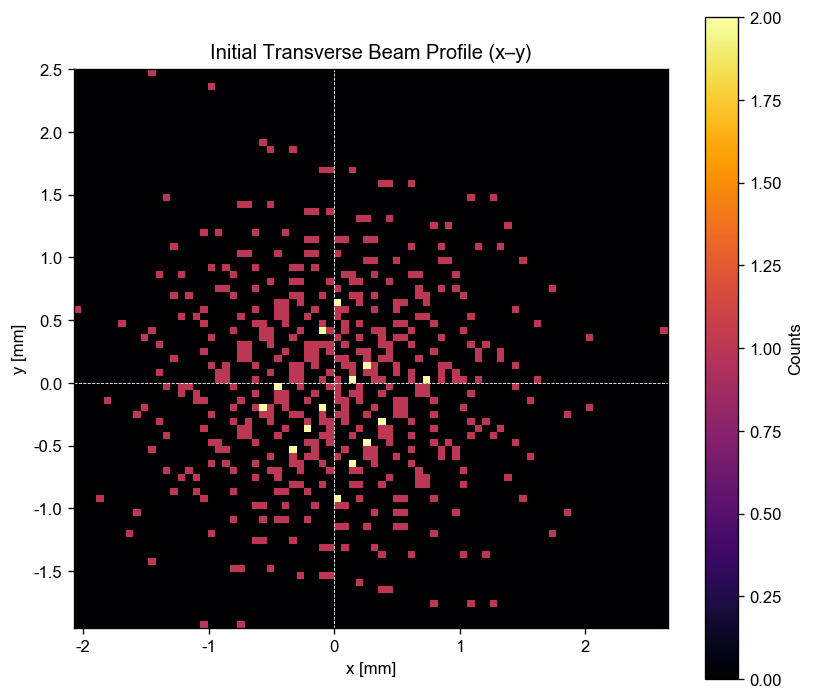

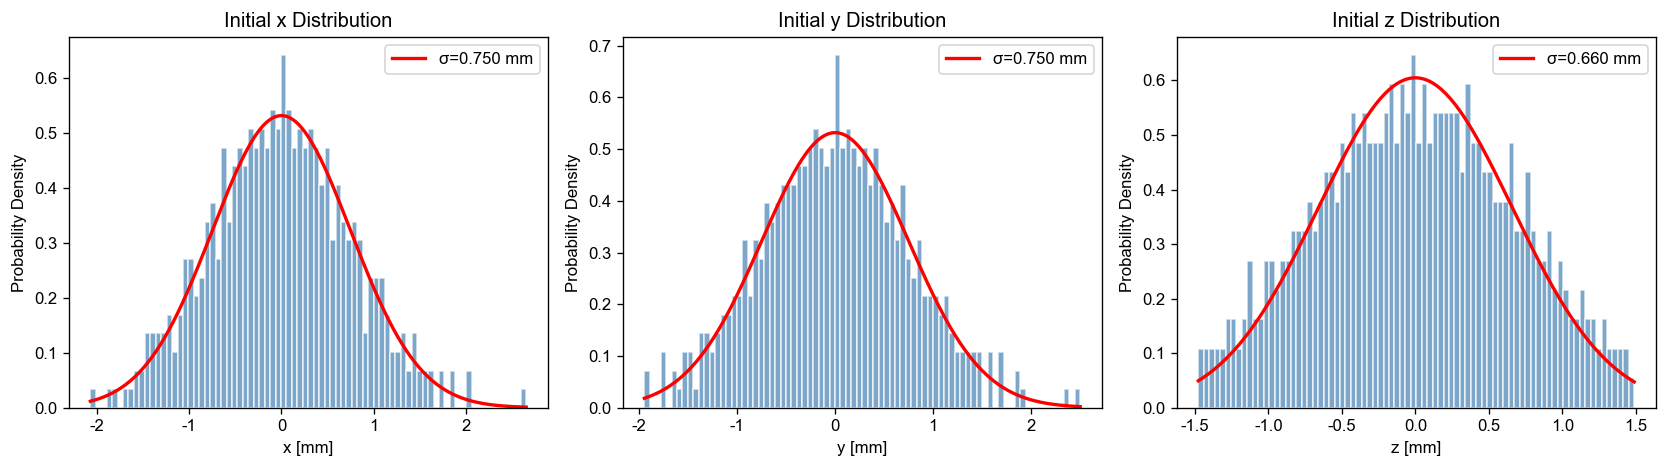

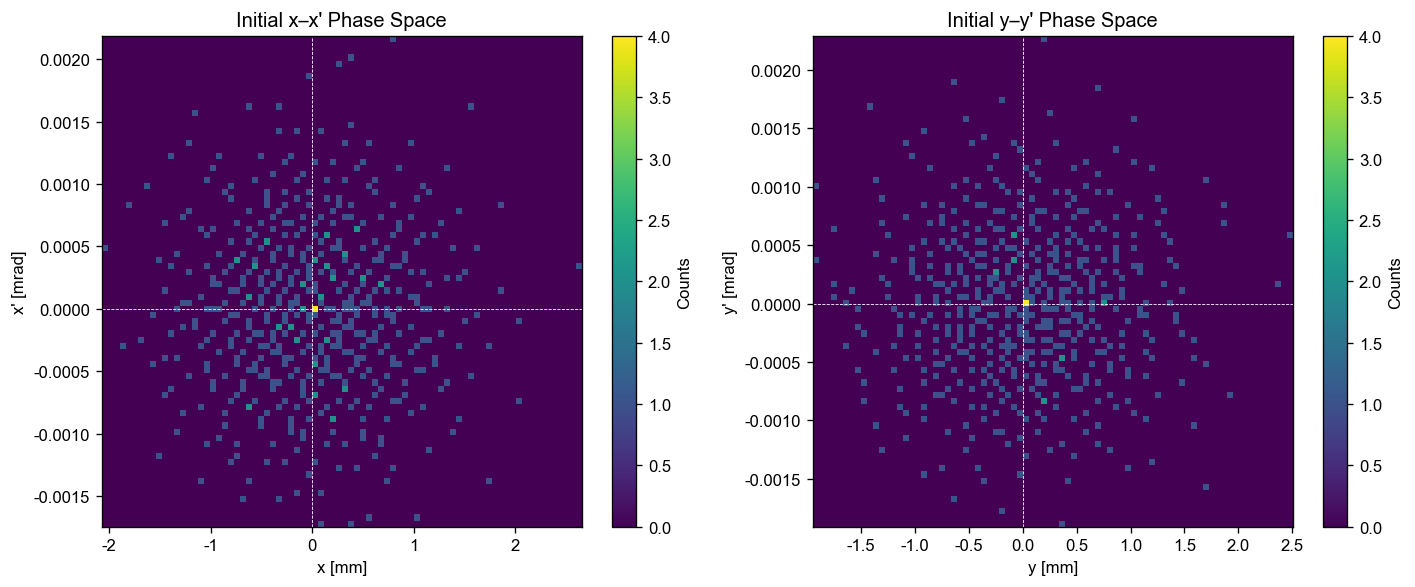

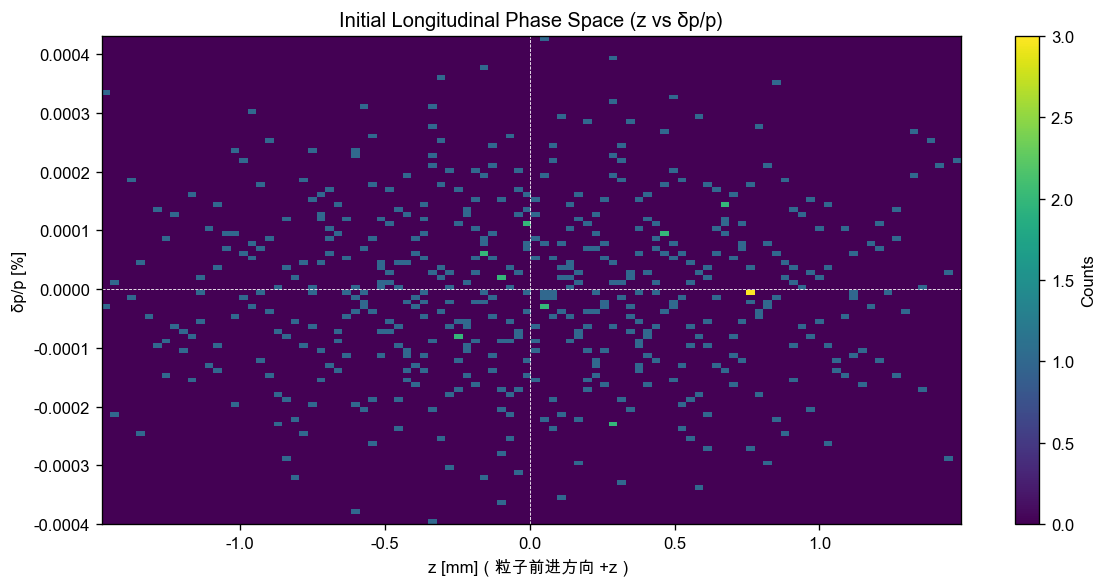

INFO: 初始束团分析完成。


In [20]:
# 读取并解析初始粒子分布

dist_initial = utils.read_astra_distribution(GEN_OUTPUT_FILE)

# 显示基本信息
print(f"\n初始分布概要：")
print(f"  粒子总数:       {dist_initial['n_particle']}")
print(f"  活跃粒子数:     {dist_initial['n_active']}")
print(f"  总电荷:         {dist_initial['total_charge']:.4f} nC")
print(f"  丢失粒子数:     {dist_initial['n_particle'] - dist_initial['n_active']}")

# ---- 统计计算 ----
ref_eV = REF_ENERGY_MEV * 1e6 if REF_ENERGY_MEV is not None else gen_params["Ref_Ekin"] * 1e6
stats_initial = utils.compute_beam_statistics(
    dist_initial,
    ref_energy_eV=ref_eV
)
utils.print_statistics(stats_initial, title="初始束团统计 (Generator 输出)")

# ---- 绘图 ----
utils.logger.info("绘制初始束团分布图...")

import matplotlib.pyplot as plt

# 图 1: 横向束斑 (x-y)
fig1 = utils.plot_transverse_scatter(dist_initial, title_prefix="Initial")
plt.show()

# 图 2: x, y, z 投影分布
fig2 = utils.plot_spatial_distributions(dist_initial, title_prefix="Initial")
plt.show()

# 图 3: 横向相空间 (x-x', y-y')
fig3 = utils.plot_transverse_phase_space(dist_initial, title_prefix="Initial")
plt.show()

# 图 4: 纵向相空间 (z vs δp/p)
fig4 = utils.plot_longitudinal_phase_space(dist_initial, title_prefix="Initial")
plt.show()

utils.logger.info("初始束团分析完成。")

## 下一步

生成的文件 `{GEN_OUTPUT_FILENAME}` 位于 `{SIM_DIR}` 下，可直接作为 ASTRA 追踪模拟的初始分布输入。

> 提示：若要清理文件，运行 `import shutil; shutil.rmtree(SIM_DIR)`